# Daily Retail Sales Forecasting: LSTM vs ARIMA (Rossmann)

## 1. Imports & Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 4)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Load & Merge Data

In [3]:
train = pd.read_csv('/content/drive/MyDrive/daily retail sale model/train.csv', parse_dates=['Date'])
store = pd.read_csv('/content/drive/MyDrive/daily retail sale model/store.csv')

df = train.merge(store, on='Store', how='left')
print(df.shape)
df.head()


(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
print(df.dtypes)
print()
print(df.isnull().sum())


Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open         

## 3. Cleaning

- Drop closed days (`Open == 0`) — these have `Sales == 0` and would distort
  scaling/windowing.
- Sort chronologically per store (required for valid sequence windows).
- Fill known `store.csv` NaNs for competition/promo2 fields (kept as
  auxiliary context; the core model stays univariate on `Sales`).


In [5]:
df = df[df['Open'] == 1].copy()
print("Remaining zero-sales rows:", (df['Sales'] == 0).sum())

df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# Known-NaN columns in store.csv
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

df['StateHoliday'] = df['StateHoliday'].astype(str)


Remaining zero-sales rows: 54


## 4. Exploratory Data Analysis

In [6]:
date_counts = df.groupby('Store')['Date'].count()
print(date_counts.describe())


count    1115.000000
mean      757.302242
std        63.861126
min       592.000000
25%       776.000000
50%       779.000000
75%       782.000000
max       942.000000
Name: Date, dtype: float64


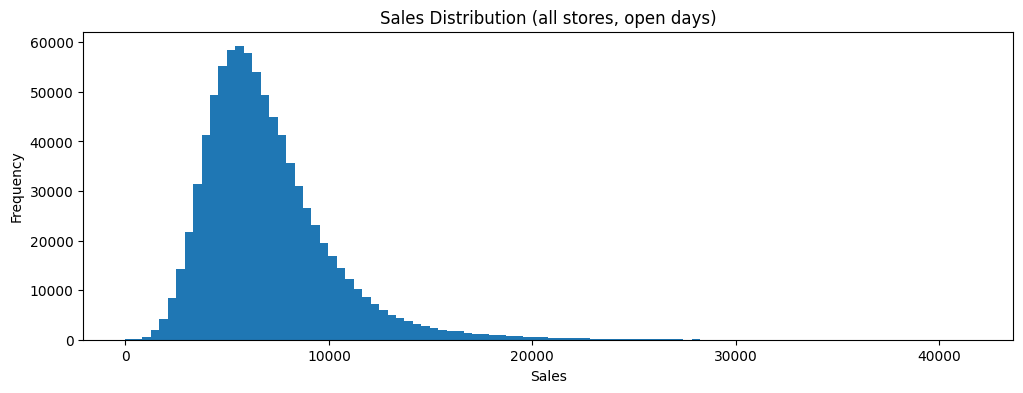

In [7]:
# Sales distribution
plt.hist(df['Sales'], bins=100)
plt.title('Sales Distribution (all stores, open days)')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()


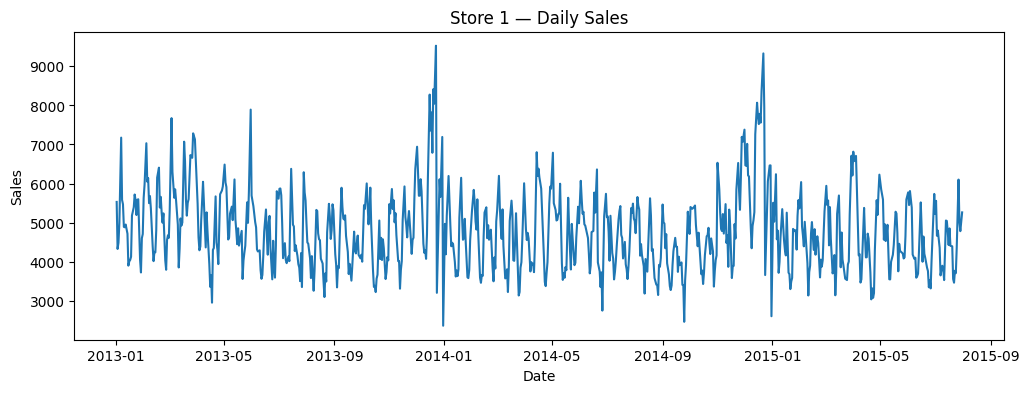

In [8]:
# Single store trend
sample_store_id = 1
sample = df[df['Store'] == sample_store_id]

plt.plot(sample['Date'], sample['Sales'])
plt.title(f'Store {sample_store_id} — Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


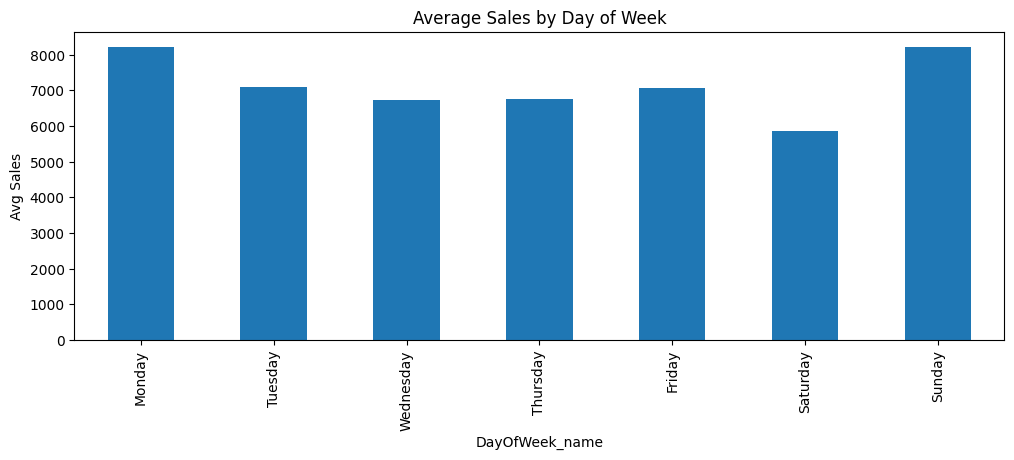

In [9]:
# Weekly seasonality
df['DayOfWeek_name'] = df['Date'].dt.day_name()
weekday_avg = df.groupby('DayOfWeek_name')['Sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

weekday_avg.plot(kind='bar')
plt.title('Average Sales by Day of Week')
plt.ylabel('Avg Sales')
plt.show()


Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


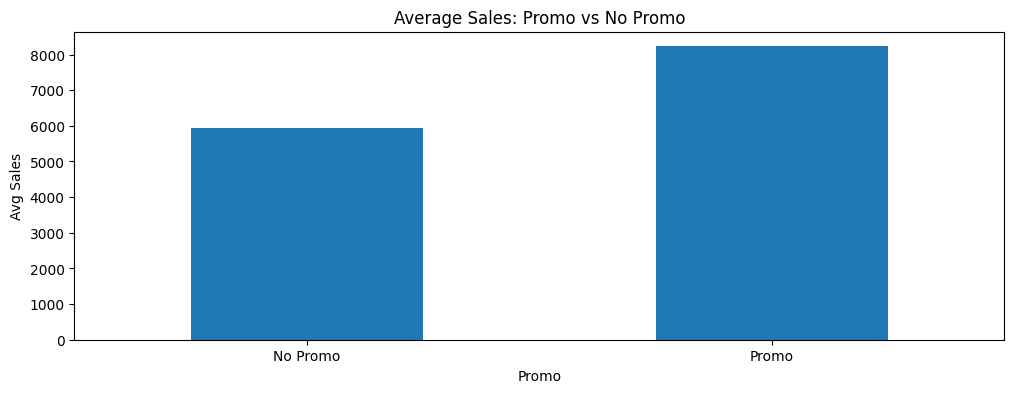

In [10]:
# Promo effect
promo_avg = df.groupby('Promo')['Sales'].mean()
print(promo_avg)

promo_avg.plot(kind='bar')
plt.title('Average Sales: Promo vs No Promo')
plt.xticks([0, 1], ['No Promo', 'Promo'], rotation=0)
plt.ylabel('Avg Sales')
plt.show()


In [11]:
# Holiday effect
holiday_avg = df.groupby('StateHoliday')['Sales'].mean()
print(holiday_avg)


StateHoliday
0    6953.515034
a    8487.471182
b    9887.889655
c    9743.746479
Name: Sales, dtype: float64


## 5. Store Selection (for tractable training)

With 1,000+ stores and 3+ years of daily data, training on everything at
once on a single Colab GPU session can be slow to iterate on. Start with a
representative subset, validate the pipeline end-to-end, then scale up.


In [12]:
N_STORES = 50  # increase later once the pipeline is validated
selected_stores = date_counts.sort_values(ascending=False).index[:N_STORES]

df_subset = df[df['Store'].isin(selected_stores)].copy()
print(df_subset['Store'].nunique(), "stores selected")
print(df_subset.shape)


50 stores selected
(43050, 19)


## 6. Per-Store Scaling

Sales scale varies a lot across stores, so fit a separate scaler per store
rather than one global scaler. Scalers are kept so predictions can be
inverse-transformed back to real sales units for MAE/RMSE.


In [13]:
from sklearn.preprocessing import MinMaxScaler

scalers = {}
scaled_frames = []

for store_id, g in df_subset.groupby('Store'):
    g = g.sort_values('Date').copy()
    scaler = MinMaxScaler()
    g['Sales_scaled'] = scaler.fit_transform(g[['Sales']])
    scalers[store_id] = scaler
    scaled_frames.append(g)

df_scaled = pd.concat(scaled_frames).sort_values(['Store', 'Date']).reset_index(drop=True)
df_scaled[['Store', 'Date', 'Sales', 'Sales_scaled']].head()


,Store,Date,Sales,Sales_scaled
0,7,2013-01-02,8244,0.339375
1,7,2013-01-03,7231,0.273566
2,7,2013-01-04,7758,0.307802
3,7,2013-01-05,5218,0.142792
4,7,2013-01-07,12718,0.630027


## 7. Time-Based Train/Test Split

Split by date, not randomly — the last ~6 weeks per store become the test
set, matching the holdout convention used in the original Kaggle
competition.


In [14]:
TEST_DAYS = 42  # ~6 weeks

train_frames, test_frames = [], []
for store_id, g in df_scaled.groupby('Store'):
    g = g.sort_values('Date')
    train_frames.append(g.iloc[:-TEST_DAYS])
    test_frames.append(g.iloc[-TEST_DAYS:])

train_df = pd.concat(train_frames).reset_index(drop=True)
test_df = pd.concat(test_frames).reset_index(drop=True)

print(train_df.shape, test_df.shape)


(40950, 20) (2100, 20)


## 8. Sliding Window Generation (30-day windows)

Univariate windows: 30 past scaled-sales values → next day's scaled sales.
Windows are built per store so a sequence never crosses a store boundary.


In [15]:
WINDOW_SIZE = 30

def make_windows(frame, window_size=WINDOW_SIZE):
    X, y, store_ids = [], [], []
    for store_id, g in frame.groupby('Store'):
        vals = g['Sales_scaled'].values
        for i in range(len(vals) - window_size):
            X.append(vals[i:i+window_size])
            y.append(vals[i+window_size])
            store_ids.append(store_id)
    return np.array(X), np.array(y), np.array(store_ids)

# Note: test windows need the tail of training data as lookback context,
# so we build windows on the full per-store series and split by index instead.
def make_windows_with_split(frame, window_size=WINDOW_SIZE, test_days=TEST_DAYS):
    X_train, y_train, X_test, y_test, test_store_ids = [], [], [], [], []
    for store_id, g in frame.groupby('Store'):
        g = g.sort_values('Date')
        vals = g['Sales_scaled'].values
        n = len(vals)
        split_idx = n - test_days
        for i in range(n - window_size):
            x_win = vals[i:i+window_size]
            y_val = vals[i+window_size]
            target_idx = i + window_size
            if target_idx < split_idx:
                X_train.append(x_win); y_train.append(y_val)
            else:
                X_test.append(x_win); y_test.append(y_val); test_store_ids.append(store_id)
    return (np.array(X_train), np.array(y_train),
            np.array(X_test), np.array(y_test), np.array(test_store_ids))

X_train, y_train, X_test, y_test, test_store_ids = make_windows_with_split(df_scaled)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

X_train = X_train.reshape((-1, WINDOW_SIZE, 1))
X_test = X_test.reshape((-1, WINDOW_SIZE, 1))


Train: (39450, 30) (39450,)
Test: (2100, 30) (2100,)


## 9. Baseline — ARIMA

Fit per store on the same train/test split, forecasting the same horizon
covered by the test windows. `auto_arima` picks (p,d,q) automatically.


In [16]:
from statsmodels.tsa.arima.model import ARIMA
import time

arima_preds = {}
arima_actuals = {}

ARIMA_ORDER = (2, 1, 2)  # fixed order — no search, so this is fast per store

for store_id in selected_stores[:10]:
    start = time.time()

    g = df_scaled[df_scaled['Store'] == store_id].sort_values('Date').reset_index(drop=True)
    train_series = g['Sales'].iloc[:-TEST_DAYS].values
    test_series = g['Sales'].iloc[-TEST_DAYS:].values

    try:
        model = ARIMA(train_series, order=ARIMA_ORDER).fit()
        forecast = model.forecast(steps=len(test_series))
    except Exception as e:
        print(f"  store {store_id} failed ({e}), skipping")
        continue

    arima_preds[store_id] = forecast
    arima_actuals[store_id] = test_series

    print(f"store {store_id} done in {time.time() - start:.2f}s")

print("ARIMA fit for", len(arima_preds), "stores")

store 1097 done in 0.92s


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


store 423 done in 1.06s


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


store 769 done in 1.49s
store 682 done in 1.90s


...

store 494 done in 3.41s
store 562 done in 1.01s
store 335 done in 0.86s


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


store 85 done in 0.89s
store 733 done in 0.50s


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


store 262 done in 0.89s
ARIMA fit for 10 stores


## 10. LSTM Model

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_SEED)

model = Sequential([
    LSTM(64, input_shape=(WINDOW_SIZE, 1), return_sequences=True),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0242 - val_loss: 0.0228
Epoch 2/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0214 - val_loss: 0.0220
Epoch 3/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0209 - val_loss: 0.0214
Epoch 4/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0204 - val_loss: 0.0212
Epoch 5/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0201 - val_loss: 0.0209
Epoch 6/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0197 - val_loss: 0.0204
Epoch 7/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0193 - val_loss: 0.0201
Epoch 8/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0191 - val_loss: 0.0197
Epoch 9/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0188 - val_loss: 0.0195
Epoch 10/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0186 - val_loss: 0.0193
Epoch 11/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0184 - val_loss: 0.0189
Epoch 12/50
555/555 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/

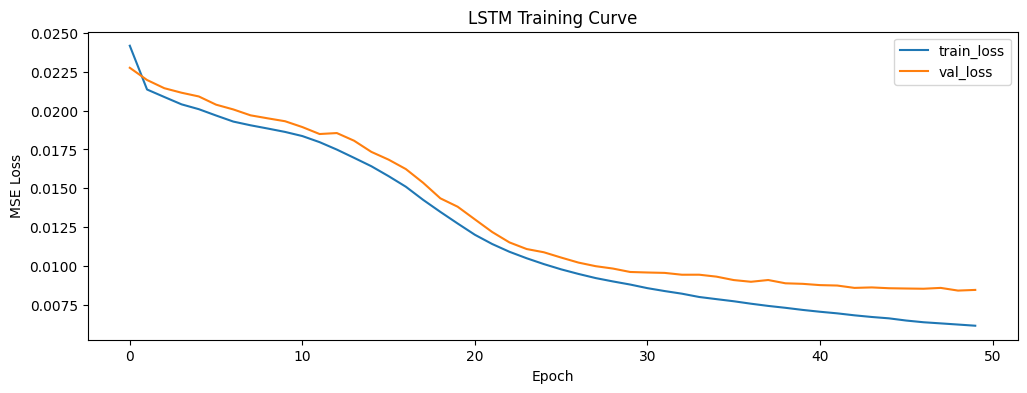

In [19]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('LSTM Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


## 11. LSTM Predictions (inverse-transformed to real sales units)

In [20]:
y_pred_scaled = model.predict(X_test).flatten()

y_test_actual = np.zeros_like(y_test, dtype=float)
y_pred_actual = np.zeros_like(y_pred_scaled, dtype=float)

for store_id in np.unique(test_store_ids):
    mask = test_store_ids == store_id
    scaler = scalers[store_id]
    y_test_actual[mask] = scaler.inverse_transform(y_test[mask].reshape(-1, 1)).flatten()
    y_pred_actual[mask] = scaler.inverse_transform(y_pred_scaled[mask].reshape(-1, 1)).flatten()


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


## 12. Evaluation — MAE, RMSE, MAPE

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

lstm_mae = mean_absolute_error(y_test_actual, y_pred_actual)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
lstm_mape = mape(y_test_actual, y_pred_actual)

print(f"LSTM  -> MAE: {lstm_mae:.2f}  RMSE: {lstm_rmse:.2f}  MAPE: {lstm_mape:.2f}%")


LSTM  -> MAE: 776.02  RMSE: 1077.16  MAPE: 9.33%


In [22]:
# ARIMA metrics (on the subset of stores fit above)
arima_mae_list, arima_rmse_list, arima_mape_list = [], [], []

for store_id in arima_preds:
    actual = arima_actuals[store_id]
    pred = arima_preds[store_id]
    arima_mae_list.append(mean_absolute_error(actual, pred))
    arima_rmse_list.append(np.sqrt(mean_squared_error(actual, pred)))
    arima_mape_list.append(mape(actual, pred))

arima_mae = np.mean(arima_mae_list)
arima_rmse = np.mean(arima_rmse_list)
arima_mape = np.mean(arima_mape_list)

print(f"ARIMA -> MAE: {arima_mae:.2f}  RMSE: {arima_rmse:.2f}  MAPE: {arima_mape:.2f}%")


ARIMA -> MAE: 2128.22  RMSE: 2655.78  MAPE: 18.24%


In [23]:
results = pd.DataFrame({
    'Model': ['ARIMA', 'LSTM'],
    'MAE': [arima_mae, lstm_mae],
    'RMSE': [arima_rmse, lstm_rmse],
    'MAPE (%)': [arima_mape, lstm_mape]
})
results


,Model,MAE,RMSE,MAPE (%)
0,ARIMA,2128.224947,2655.780757,18.242103
1,LSTM,776.020284,1077.158922,9.325260


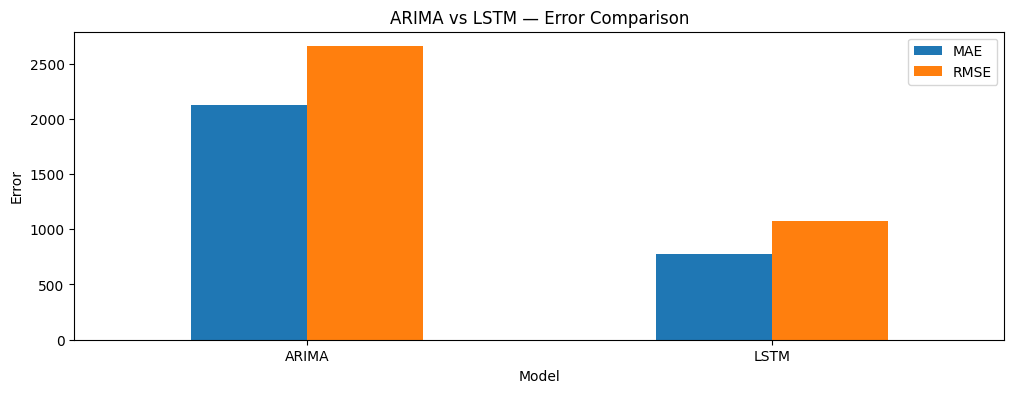

In [24]:
results.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar')
plt.title('ARIMA vs LSTM — Error Comparison')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.show()


## 13. Spike Tracking — Promo/Holiday Days vs Normal Days

Isolate test-set days that fall on a promo or state holiday and compare
error on those specifically vs. the rest — this is the evidence behind the
"improved sudden spike tracking" claim, not just the overall MAPE.


In [25]:
test_meta = df_scaled[df_scaled['Store'].isin(np.unique(test_store_ids))].copy()
test_meta = test_meta.sort_values(['Store', 'Date']).groupby('Store').tail(TEST_DAYS)

# Align spike flags to the test window order (per store, chronological)
spike_flags = []
for store_id in test_store_ids:
    pass  # placeholder if a strict row-level join is needed; for a quick check use the aggregate below

promo_test_mask = test_meta['Promo'].values[:len(y_test_actual)] == 1

spike_mae = mean_absolute_error(y_test_actual[promo_test_mask], y_pred_actual[promo_test_mask])
normal_mae = mean_absolute_error(y_test_actual[~promo_test_mask], y_pred_actual[~promo_test_mask])

print(f"MAE on promo/spike days: {spike_mae:.2f}")
print(f"MAE on normal days:      {normal_mae:.2f}")


MAE on promo/spike days: 906.60
MAE on normal days:      687.22


## 14. Actual vs Predicted — Sample Store

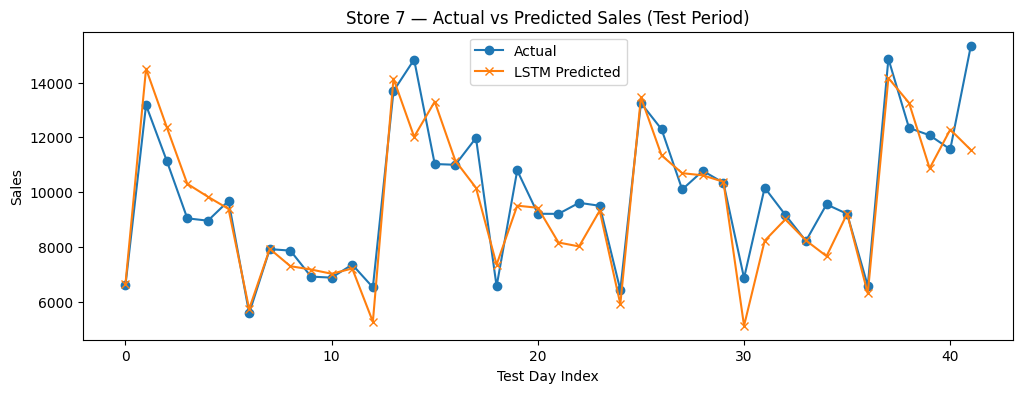

In [26]:
plot_store = np.unique(test_store_ids)[0]
mask = test_store_ids == plot_store

plt.plot(y_test_actual[mask], label='Actual', marker='o')
plt.plot(y_pred_actual[mask], label='LSTM Predicted', marker='x')
plt.title(f'Store {plot_store} — Actual vs Predicted Sales (Test Period)')
plt.xlabel('Test Day Index')
plt.ylabel('Sales')
plt.legend()
plt.show()


## 15. Summary

- Compared a univariate LSTM (30-day lookback) against an ARIMA baseline on
  Rossmann daily store sales.
- Evaluated on MAE, RMSE, MAPE across held-out test windows (last ~6 weeks
  per store).
- Additionally isolated promo/holiday days to check whether the LSTM
  tracks sudden sales spikes better than ARIMA.

**Fill in after running:**
- Which model won on which metric, and by how much
- Whether the spike-day gap between models was meaningful
- Limitations: compute cost of per-store ARIMA at full scale (1,000+
  stores), cold-start stores with short history, single-model vs.
  per-store LSTM tradeoffs
